In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [2]:
import spikeinterface.full as si
from configuration import figure_folder
#import spikeinterface as si
from pathlib import Path
si.set_global_job_kwargs(n_jobs=0.8, pool_engine='process')

In [3]:
from configuration import base_path
global_name = 'clustering_drifting'
# dataset_name = 'Neuronexus-32_50_300.s'
# dataset_name = 'Neuropixels1-128_250_100.s'
# dataset_name = 'Neuropixels1-384_500_600.s'
dataset_name = 'Neuropixels1-384_500_1800.s'

motion_folder = base_path / global_name / dataset_name / 'motion'
study_folder = base_path / global_name / dataset_name / 'study'
si.set_global_job_kwargs(n_jobs=0.8, pool_engine='process')

In [4]:
from spikeinterface.benchmark.benchmark_clustering import ClusteringStudy
study = ClusteringStudy(study_folder)
study

ClusteringStudy study 
  datasets: 2 ['static', 'corrected']
  cases: 8 [('iterative-hdbscan', 'static'), ('iterative-hdbscan', 'corrected'), ('iterative-isosplit', 'static'), ('iterative-isosplit', 'corrected'), ('graph-clustering', 'static'), ('graph-clustering', 'corrected'), ('kilosort-clustering', 'static'), ('kilosort-clustering', 'corrected')]
  computed: 8

In [5]:

study.colors_by_case = {
    ('iterative-hdbscan', 'static'): "#5855F2",
    ('iterative-hdbscan', 'corrected'): "#55CDF2",
    ('iterative-isosplit', 'static'): "#00FF22",
    ('iterative-isosplit', 'corrected'): "#A1FF84FF",
    ('graph-clustering', 'static'): "#BE4732",
    ('graph-clustering', 'corrected'): "#E6A99F",
    ('kilosort-clustering', 'static'): "#FF00BF",
    ('kilosort-clustering', 'corrected'): "#FF86E1",
}

# change labels to avoid re run
study.cases[('iterative-hdbscan', 'static')]['label'] = 'Iter-HDBSCAN | static'
study.cases[('iterative-hdbscan', 'corrected')]['label'] = 'Iter-HDBSCAN | motion-corrected'
study.cases[('iterative-isosplit', 'static')]['label'] = 'Iter-ISOSPLIT | static'
study.cases[('iterative-isosplit', 'corrected')]['label'] = 'Iter-ISOSPLIT | motion-corrected'
study.cases[('graph-clustering', 'static')]['label'] = 'Global-Louvain | static'
study.cases[('graph-clustering', 'corrected')]['label'] = 'Global-Louvain | motion-corrected'
study.cases[('kilosort-clustering', 'static')]['label'] = 'KS-clustering | static'
study.cases[('kilosort-clustering', 'corrected')]['label'] = 'KS-clustering | motion-corrected'


In [6]:
all_cases = list(study.cases.keys())
static_cases = all_cases[::2]
drifting_cases = all_cases[1::2]
print(static_cases)
print(drifting_cases)

[('iterative-hdbscan', 'static'), ('iterative-isosplit', 'static'), ('graph-clustering', 'static'), ('kilosort-clustering', 'static')]
[('iterative-hdbscan', 'corrected'), ('iterative-isosplit', 'corrected'), ('graph-clustering', 'corrected'), ('kilosort-clustering', 'corrected')]


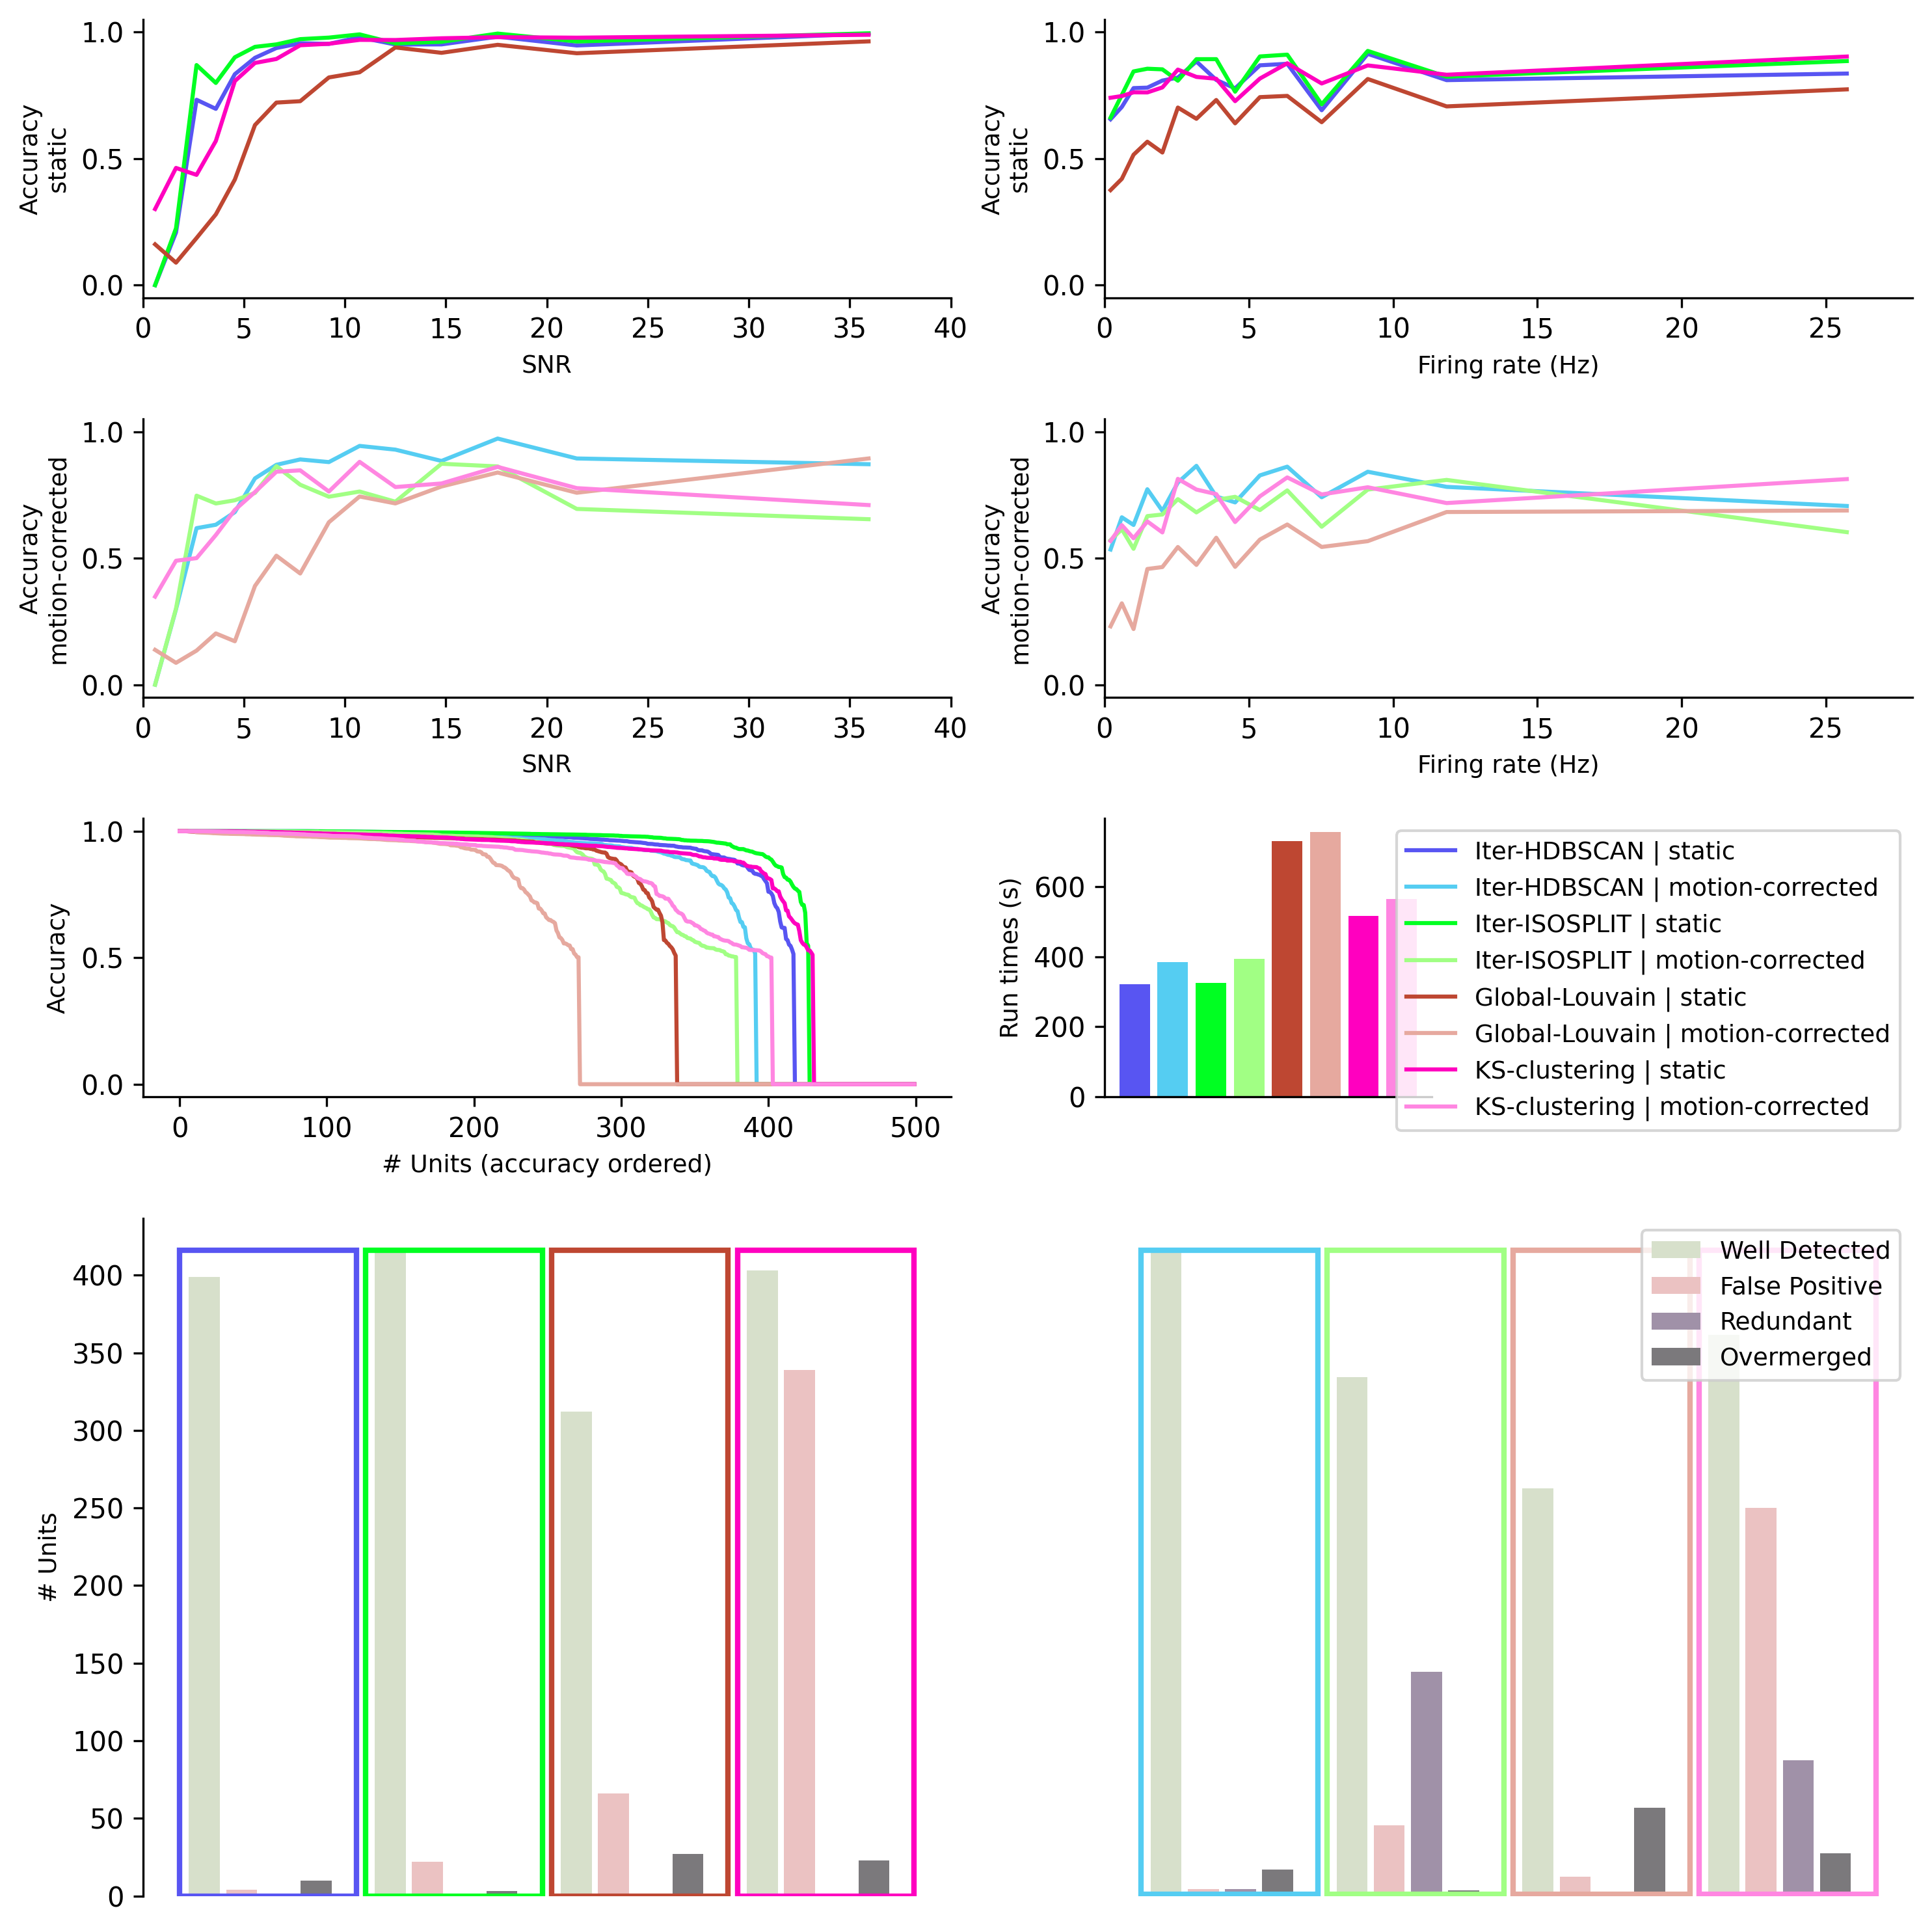

In [14]:
%matplotlib inline
myparams = {
    'axes.titlesize' : 10,
    'axes.labelsize' : 9,
    'legend.fontsize': 9,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
}

import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis, plot_study_legend
from matplotlib.gridspec import GridSpec


with mpl.rc_context(myparams):

    fig = plt.figure(figsize=(10,10), dpi=300)
    
    gs = GridSpec(5, 12) #, hspace=0.8)
    
    ax1 = fig.add_subplot(gs[0,:6])
    ax2 = fig.add_subplot(gs[1,:6])
    ax3 = fig.add_subplot(gs[0, 6:])
    ax4 = fig.add_subplot(gs[1, 6:])

    ax5 = fig.add_subplot(gs[2, 0:6])
    ax6 = fig.add_subplot(gs[2, 6:9])
    ax7 = fig.add_subplot(gs[2, 9:12])

    ax8 = fig.add_subplot(gs[3:5, 0:6])
    ax9 = fig.add_subplot(gs[3:5, 6:12])
    
    plot_study_legend(study, case_keys=all_cases, ax=ax7)

    _ = study.plot_performances_vs_snr(case_keys=static_cases, performance_names=['accuracy'],
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True, 
                                        show_legend=False, axs=[ax1],
                                        show_scatter=False,
                                        num_bin_average=15,
                                        scatter_size=1,
                                        scatter_alpha=0.25,
                                        metric_dataset_reference='static',
                                        )
    ax1.set_ylabel('Accuracy\nstatic')
    _ = study.plot_performances_vs_snr(case_keys=drifting_cases, performance_names=['accuracy'], 
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True, 
                                        show_legend=False,  axs=[ax2],
                                        show_scatter=False,
                                        num_bin_average=15,
                                        scatter_size=1,
                                        scatter_alpha=0.25,

                                        metric_dataset_reference='static',
                                        )
    
    
    ax2.set_ylabel('Accuracy\nmotion-corrected')
    for ax in (ax1, ax2):
        ax.set_xlim(0, 40)
        ax.set_xlabel('SNR')


    _ = study.plot_performances_vs_firing_rate(case_keys=static_cases, performance_names=['accuracy'], 
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True, 
                                        show_legend=False,  axs=[ax3],
                                        show_scatter=False,
                                        num_bin_average=15,
                                        scatter_size=1,
                                        scatter_alpha=0.25,

                                        metric_dataset_reference='static',
                                        )
    ax3.set_xlabel('Firing rate (Hz)')
    ax3.set_ylabel('Accuracy\nstatic')

    _ = study.plot_performances_vs_firing_rate(case_keys=drifting_cases, performance_names=['accuracy'], 
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True, 
                                        show_legend=False,  axs=[ax4],
                                        show_scatter=False,
                                        num_bin_average=15,
                                        scatter_size=1,
                                        scatter_alpha=0.25,

                                        metric_dataset_reference='static',
                                        )
    ax4.set_xlabel('Firing rate (Hz)')
    ax4.set_ylabel('Accuracy\nmotion-corrected')

    for ax in (ax3, ax4):
        ax.set_xlim(0, 28)



    study.plot_performances_ordered(case_keys=all_cases, performance_names=['accuracy'],
                                    show_legend=False, axs=[ax5])
    ax5.set_title('')
    ax5.set_xlabel('# Units (accuracy ordered)')
    ax5.set_ylabel('Accuracy')

    for ax in (ax1, ax2, ax3, ax4, ax5):
        ax.set_yticks([0, 0.5, 1])

    _ = study.plot_run_times(case_keys=all_cases,ax=ax6)
    ax6.set_xticks([])
    ax6.set_xticklabels([])
    despine(ax6)

    count_colors = dict(
        num_well_detected="#D7E0CB",
        num_false_positive="#EBC2C2",
        num_redundant="#A091A8",
        num_overmerged="#7B797C",
    )    


    _ = study.plot_unit_counts(case_keys=static_cases,  
                               columns=['num_well_detected', 'num_false_positive', 'num_redundant', 'num_overmerged',],
                               colors=count_colors,
                               xticks_rotation=0.,
                               revert_bad=False,
                               ax=ax8)
    ax8.get_legend().remove()
    _ = study.plot_unit_counts(case_keys=drifting_cases,  
                               columns=['num_well_detected', 'num_false_positive', 'num_redundant', 'num_overmerged',],
                               colors=count_colors,
                               xticks_rotation=0.,
                               revert_bad=False,
                               ax=ax9)
    ax9.get_legend().set_loc('upper right')

    for ax in (ax8, ax9):

        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.spines["bottom"].set_visible(False)
        # ax.set_yticks([ 0, 200, 400])
        # ax.set_yticklabels(["0", "200", "400"])
    ax9.spines['left'].set_visible(False)
    ax9.set_yticks([])
    ax8.set_ylabel('# Units')

    
    # fig.tight_layout(h_pad=1.5, w_pad=0.0)
    fig.tight_layout(h_pad=1.5, w_pad=0.0)


    fig.savefig(figure_folder / 'figure_clustering.png')
    fig.savefig( figure_folder / 'figure_clustering.pdf')